In [72]:
import pickle
import numpy as np
import matplotlib
import pickle

def to_pickle(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

In [73]:
# 在这里修改生成数据集的类型
# neg/non-neg: 'nn'
# neg/pos: 'np'
data_type = 'np'

In [ ]:
# 读入数据集
featurePath = "/home/st/disk0/ni/MMSA/MOSEI/unaligned_50.pkl"
with open(featurePath, 'rb') as f:
    dataset = pickle.load(f)
print(dataset.keys)

<built-in method keys of dict object at 0x7f0cd56a37c0>


In [75]:
dataset = dataset['test']
def getText(txt):
    txt = txt.lower()
    for ch in '!"#$%&()*+,-./:;<=>?@[\\]^_‘{|}~':
        txt = txt.replace(ch, " ")   #将文本中特殊字符替换为空格
    return txt
word = []
for i in range(len(dataset['raw_text'])):
    text = ''
    text += dataset['raw_text'][i]
    words = getText(text).split()
    word.append(words)
dataset['raw_text'] = word

In [76]:
'''text_list 储存sample的非语气词
    sentiment_list 储存sample情感标签
    name_lsit 储存sample名称id'''
text_list = []
sentiment_list = []
name_list = []
stop_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

data = dataset
# 删除末尾数字和下划线
def delete_end_number(str):
    # -6rXp3zJ3kc$_$9
    str_list = list(str)[::-1]
    over = len(str_list)
    for index, i in enumerate(str_list):
        if i == '_':
            over = index + 2
            break
    return str[:len(str_list) - over]
name_dict = []

for i in range(len(data['id'])):
    new_text, audio_list, vision_list = [], [], []
    for word in data['raw_text'][i]:
        if word not in stop_words: new_text.append(word)
    text_list.append(new_text)
    sentiment_list.append(data['classification_labels'][i])
    name_list.append(data['id'][i])
    if delete_end_number(data['id'][i]) not in name_dict:
        name_dict.append(delete_end_number(data['id'][i]))
label_cls = data['classification_labels']
index_neg = np.where(label_cls == 0)
index_nonneg = np.where((label_cls == 1) | (label_cls == 2))
audio = np.mean(data['audio'], axis=1)
vision = np.mean(data['vision'], axis=1)
print(len(name_dict))
print(len(text_list), len(audio), len(vision), len(sentiment_list), len(name_list))

676
4659 4659 4659 4659 4659


In [77]:
str_list = list(word[0])
print(str_list)
str_list = list(word[0])[::-1]#倒叙
print(str_list)
print(delete_end_number('-6rXp3zJ3kc$_$9'))

['d']
['d']
-6rXp3zJ3kc


In [78]:
print(data['id'][5])

-9y-fZ3swSY$_$3


In [79]:
'''text_list 储存sample的非语气词
    sentiment_list 储存sample情感标签
    name_lsit 储存sample名称id'''
text_list = []
sentiment_list = []
name_list = []
stop_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

data = dataset
# 删除末尾数字和下划线
def delete_end_number(str):
    # -6rXp3zJ3kc$_$9
    str_list = list(str)[::-1]#倒序
    over = len(str_list)
    for index, i in enumerate(str_list):
        if i == '_':
            over = index + 2
            break
    return str[:len(str_list) - over]
name_dict = []

for i in range(len(data['id'])):
    new_text = []
    for word in data['raw_text'][i]:
        if word not in stop_words: new_text.append(word)
    text_list.append(new_text)
    sentiment_list.append(data['classification_labels'][i])
    name_list.append(data['id'][i])
    if delete_end_number(data['id'][i]) not in name_dict:
        name_dict.append(delete_end_number(data['id'][i]))
print(len(name_dict))
print(len(text_list), len(sentiment_list), len(name_list))

676
4659 4659 4659


In [80]:
print(sentiment_list[0])

2.0


In [81]:
import numpy as np
# 制作 word 的 one-hot 映射字典
word_number_dict = {} # {word, number}
word_index_dict = {} # {word, index}
word_index = 0
word_threshold = 50     # 词语阈值，小于该值不会被算在统计之中

# 生成new_text_list 包含 word_list sentiment_list nama_list
new_text_list = []
for index, word_list in enumerate(text_list):
    new_text_list.append((word_list, sentiment_list[index], name_list[index]))

# 统计word_number_dict
for (word_list, sentiment, sample_id) in new_text_list:
    for word in word_list:
        if word not in word_number_dict:
            word_number_dict[word] = 1
        else: word_number_dict[word] += 1

# 统计word_index_dict 剔除一部分数量<=word_threshold的word       
for (word_list, sentiment, sample_id) in new_text_list:
    for word in word_list:
        if word_number_dict[word] > word_threshold and word not in word_index_dict:#小于thrs没有对应的index
            word_index_dict[word] = word_index
            word_index += 1

def one_hot(str):
    number_tensor = np.zeros(word_index)
    if str in word_index_dict:
        number_tensor[word_index_dict[str]] = 1
    return number_tensor

print("word_index:",word_index)
#to_pickle(new_text_list, 'sample_list.pkl')

word_index: 115


In [82]:
a=np.zeros(5)
print(a[:])

[0. 0. 0. 0. 0.]


In [83]:
word_dict = {}
#word_dict统计经过频率过滤之后，词在不同n/p情感下的个数
for (word_list, sentiment, sample_id) in new_text_list:
    for word in word_list:
        if word in word_index_dict:
            if word not in word_dict:
                word_dict[word] = [0, 0]
            if data_type=='np':
                word_dict[word][int(sentiment > 1)] += 1#统计pos和neg
            elif data_type=='nn':
                word_dict[word][int(sentiment >= 1)] += 1#统计nn和neg
print(len(word_dict))
#to_pickle(word_dict, 'word_dict.pkl')

115


In [84]:
# 统计每个视频所有 sample 的词频向量总和 (neg, pos)
sample_sum_dict = {}

all_neg_sum = np.zeros(word_index)
all_pos_sum = np.zeros(word_index)

for index, (word_list, sentiment, sample_id) in enumerate(new_text_list):
    sample_id = index#这一句有没有都一样 因为index永远等于sample_id 并且永远不存在重复的sample_id(上文对应的name_id)
    neg_sum = np.zeros(word_index)
    pos_sum = np.zeros(word_index)

    for word in word_list:
        if sentiment < 1: neg_sum += one_hot(word)#一个sentiment对应的是一整个video，所以如果为neg的化,pos就是零向量
        if data_type=='nn':
            if sentiment >= 1: pos_sum += one_hot(word)
        elif data_type=='np':
            if sentiment > 1: pos_sum += one_hot(word)
    
    if sample_id not in sample_sum_dict:
        sample_sum_dict[sample_id] = [neg_sum, pos_sum]
    else:#多余了 不存在重复的sample id
        sample_sum_dict[sample_id][0] += neg_sum
        sample_sum_dict[sample_id][1] += pos_sum
    
    all_neg_sum += neg_sum
    all_pos_sum += pos_sum

all_word_number = 0
for (word_list, sentiment, sample_id) in new_text_list:
    all_word_number += len(word_list)
print(all_word_number)
print(np.sum(all_neg_sum) + np.sum(all_pos_sum))

46706
11101.0


In [85]:
# 创建 neg 和 pos 的合并向量，方便后续 cal 操作
from tqdm import tqdm

sample_list = list(sample_sum_dict.keys())
all_neg_sum_array = np.array([np.zeros(word_index)])#所有sampleid对应的neg行向量连在一起
all_pos_sum_array = np.array([np.zeros(word_index)])#对应的pos 连在一起

for key in tqdm(sample_sum_dict):
    all_neg_sum_array = np.concatenate((all_neg_sum_array, np.array([sample_sum_dict[key][0]])), axis = 0)
    all_pos_sum_array = np.concatenate((all_pos_sum_array, np.array([sample_sum_dict[key][1]])), axis = 0)
all_neg_sum_array = all_neg_sum_array[1:]#舍去第一行
all_pos_sum_array = all_pos_sum_array[1:]
print(all_neg_sum_array.shape)
print(all_pos_sum_array.shape)

100%|██████████| 4659/4659 [00:01<00:00, 3032.89it/s]

(4659, 115)
(4659, 115)


In [86]:
eps = 1e-6
# 计算指定划分中 neg 和 pos 集合的总向量
def sample_sum_cal(sample_array):
    pos_vec = np.sum(all_pos_sum_array[sample_array], axis = 0)
    neg_vec = np.sum(all_neg_sum_array[sample_array], axis = 0)
    return neg_vec, pos_vec

"""
# 计算指定划分中 neg 和 pos 集合的偏移价值
def sample_rate_cal(neg_vec1, pos_vec1):
    n_rate = neg_vec1 / (neg_vec1 + pos_vec1 + eps)
    p_rate = 0.5
    return np.sum(np.abs(n_rate - p_rate))
"""

# 计算指定划分中 neg 和 pos 集合的偏移价值
# def sample_rate_cal(neg_vec1, pos_vec1, neg_vec2, pos_vec2):
#     n_rate = neg_vec1 / (neg_vec1 + pos_vec1 + eps)
#     p_rate = pos_vec2 / (neg_vec2 + pos_vec2 + eps)
#     return np.sum(np.abs(n_rate - p_rate))

def sample_rate_cal(neg_vec1, pos_vec1, neg_vec2, pos_vec2):
    n_rate = neg_vec1 / (neg_vec1 + pos_vec1 + eps)
    p_rate = pos_vec1 / (neg_vec1 + pos_vec1 + eps)
    return np.sum(np.abs(n_rate - p_rate))

# 价值计算
def value_cal(data_split):
    data_split = np.array(data_split)
    neg_vec1, pos_vec1 = sample_sum_cal(data_split.astype(bool))
    # neg_vec2, pos_vec2 = sample_sum_cal((1-data_split).astype(bool))
    value = sample_rate_cal(neg_vec1, pos_vec1, all_neg_sum, all_pos_sum)
    # value = sample_rate_cal(neg_vec1, pos_vec1, neg_vec2, pos_vec2)
    return value

sample_sum_cal(np.ones(len(all_pos_sum_array)).astype(bool))#如果是一个二维list，sum会把list对应位置相加，返回list，np.sum则相加所有数字返回一个数字

(array([ 11.,  44.,  15.,  28.,  82.,  65.,  43.,  58.,  34.,  47.,  81.,
         26., 172., 215.,  42.,  27.,  32.,  43.,  16.,  57.,  21.,  11.,
         32.,  19.,  17.,  21.,  16.,  39.,  24.,  30.,  17.,  21.,  17.,
         10.,  47.,  20.,  36.,  29.,  14.,  26.,  53., 104.,  22.,  14.,
          6.,  31.,  74.,  73.,  83.,  35.,   9., 137.,  20.,  18.,  26.,
         33.,  10.,  12.,  39.,  73.,  19.,  30.,  26.,  19.,   9.,  13.,
         52.,   8.,  18.,  18.,   9.,  19.,  20.,  21.,  26.,  10.,  31.,
        185., 241.,  31.,  41.,  11.,   9.,   2.,  48., 244.,  16.,  74.,
          6.,  40.,   7.,  22.,  21.,   5.,  23.,  34.,  94.,  22.,  16.,
         29.,  26.,  27.,  12.,  24.,  16.,  33.,   7.,  10.,  12.,  17.,
         16.,  11.,   9.,   6.,  51.]),
 array([ 50., 114.,  48.,  38., 163., 136.,  97., 105.,  28.,  81., 136.,
         49., 178., 180., 132.,  62.,  46.,  83.,  48.,  42.,  24.,  59.,
        112.,  64.,  44.,  53.,  44.,  51.,  25.,  48.,  36.,  53.,  34.

In [87]:
np.ones(len(all_pos_sum_array)).astype(bool)

array([ True,  True,  True, ...,  True,  True,  True])

In [88]:
# # 模拟退火
# import numpy as np
# import requests
# import random
# import pickle
# import time
# import math
# import os
# import multiprocessing
# from math import floor, radians, cos, sin, asin, sqrt, exp

# history_list = []

# # 扰动函数
# def change(data_split):
#     choice = random.random() * 3
#     if choice <= 1:
#         i = 0
#         j = 0
#         while(1):
#             i = floor(random.random() * len(data_split))
#             j = floor(random.random() * len(data_split))
#             if i != j and i != 0 and j != 0 and i != len(data_split)-1 and j != len(data_split)-1:
#                 break
#         data_split[i], data_split[j] = data_split[j], data_split[i]
#     elif choice <= 2:
#         a = 0
#         b = 0
#         while(1):
#             a = floor(random.random() * len(data_split))
#             b = floor(random.random() * len(data_split))
#             if a != 0 and b != 0 and a != len(data_split)-1 and b != len(data_split)-1:
#                 break
#         dataBet = data_split[min(a, b): max(a, b) + 1]
#         data_split[min(a, b): max(a, b) + 1] = dataBet[::-1]
#     else:
#         a = 0
#         b = 0
#         c = 0 
#         while(1):
#             a = floor(random.random() * len(data_split))
#             b = floor(random.random() * len(data_split))
#             c = floor(random.random() * len(data_split))
#             if a != 0 and b != 0 and c != 0 and a != len(data_split)-1 and b != len(data_split)-1 and c != len(data_split)-1:
#                 break
#         a1 = min(min(a, b), c)
#         c1 = max(max(a, b), c)
#         b1 = a + b + c - a1 - c1
#         dataBet = data_split[a1: b1 + 1]
#         for i in range(len(dataBet)):
#             data_split.insert(c1 + 1, dataBet[len(dataBet) - i - 1])
#         data_split[a1: b1 + 1] = []
#     return data_split

# # 检查新点是否保留
# def check(new_value, old_value, T):
#     if new_value < old_value: return 1
#     if exp((old_value - new_value) / T) > random.random(): return 1
#     else: return 0

# def main_process(index):
#     test_number = 2259 # 4659
#     alpha = 0.99
#     T = 0.1
#     i = 0
#     numbers = 200
#     data_split = [1] * test_number + [0] * (len(sample_list) - test_number)
#     random.shuffle(data_split)
#     now_data_split = data_split
#     for i in range(400):
#         print(value_cal(now_data_split), T, i)
#         for j in range(int(numbers)):
#             new_data_split = change(now_data_split.copy())
#             new_value, old_value = (value_cal(new_data_split), value_cal(now_data_split))
#             if check(new_value, old_value, T) == 1:
#                 now_data_split = new_data_split
#         T *= alpha
#         numbers *= 1.0008
#         with open(f'/home/share/liuyitong/code/MAGcode/processed_data/{data_type}/text{index}.pkl', 'wb') as f:
#             pickle.dump(now_data_split, f)
#     print(index, value_cal(now_data_split))
    
# if __name__ == "__main__":
#     main_process(0)
#     """for index in range(32):
#         check_process = multiprocessing.Process(target = main_process, args = (index, ))
#         check_process.daemon = True
#         check_process.start()
    
#     for i in range(1000):
#         time.sleep(10)"""

In [89]:
with open(f'/home/st/IFL4MSA/{data_type}/text0.pkl', 'rb') as f:
    now_data_split = pickle.load(f)
test_data_split = now_data_split
test_sample_list = []
train_sample_list = []
for index, i in enumerate(test_data_split):
    if i == 1: test_sample_list.append(sample_list[index])#0.pkl当中的数据，如果值为1说明需要装入test 非1装入train当中

for sample in sample_list:
    if sample not in test_sample_list:
        train_sample_list.append(sample)
    
print(len(train_sample_list), len(test_sample_list))

2459 2200


In [90]:
def get_word_dict(sample_list):
    sample_word_dict = {}
    for index, (word_list, sentiment, sample_id) in enumerate(new_text_list):
        sample_id = index
        if sample_id not in sample_list: continue
        if sample_id not in sample_word_dict:
            sample_word_dict[sample_id] = [[], []]
        for word in word_list:
            if sentiment < 1: sample_word_dict[sample_id][0].append(word)
            if data_type=='np':
                if sentiment > 1: sample_word_dict[sample_id][1].append(word)#np
            elif data_type=='nn':
                if sentiment >= 1: sample_word_dict[sample_id][1].append(word)#nn
    
    return sample_word_dict

train_data_dict = get_word_dict(train_sample_list)
test_data_dict = get_word_dict(test_sample_list)
all_sample_dict = get_word_dict(sample_list)

In [91]:
def sample_statistics(sample_dict):
    print(len(sample_dict))

    word_dict = [{}, {}]
    for sample_id in sample_dict:
        for word in sample_dict[sample_id][0]:
            if word in word_dict[0]: word_dict[0][word] += 1
            else: word_dict[0][word] = 1
        for word in sample_dict[sample_id][1]:
            if word in word_dict[1]: word_dict[1][word] += 1
            else: word_dict[1][word] = 1

    word_dict_0 = sorted(word_dict[0].items(), key = lambda x: x[1], reverse = True)
    word_dict_1 = sorted(word_dict[1].items(), key = lambda x: x[1], reverse = True)

    return word_dict_0, word_dict_1

# train_word_dict_0, train_word_dict_1 = sample_statistics(train_data_dict)
test_word_dict_0, test_word_dict_1 = sample_statistics(test_data_dict)
all_word_dict_0, all_word_dict_1 = sample_statistics(all_sample_dict)

2200
4659


In [92]:
def Mybar(word_dict_0, word_dict_1, path):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import numpy as np

    %matplotlib inline
    data0 = word_dict_0[:100]#只画100个-
    data1 = word_dict_1[:100]

    data2 = []
    data0_x = []
    data0_y = []
    data1_x = []
    data1_y = []
    axis_x = []

    for i in data1:
        data2.append(i[0])

    print(data2)
    jShu = 0
    for index, i in enumerate(data0):
        if i[0] in data2:
            data0_x.append(3 * jShu)
            data0_y.append(i[1])

            index2 = data2.index(i[0])
            axis_x.append(i[0])
            data1_x.append(3 * jShu + 1)
            data1_y.append(data1[index2][1])
            axis_x.append(' ')
            axis_x.append(' ')
            jShu += 1
    plt.figure(figsize = (30, 12))
    plt.bar(data0_x, data0_y, align = 'center', label = "Negtive", color = 'slateblue')
    if data_type == 'nn':
        plt.bar(data1_x, data1_y, label = "Non-negtive", color = 'darkorange')
    elif data_type == 'np':
        plt.bar(data1_x, data1_y, label = "Postive", color = 'darkorange')
    plt.legend(fontsize=30)
    plt.xlabel('Class', fontsize=40)
    plt.ylabel('Number', fontsize=40)
    plt.xticks(np.arange(0, jShu * 3), axis_x, fontsize=5)
    plt.yticks(fontsize=30)
    plt.title(path, fontsize=30)
    plt.savefig(f'{path}.pdf')
    plt.show()

In [93]:
# Mybar(train_word_dict_0, train_word_dict_1)

['one', 'like', 'really', 'people', 'going', 'good', 'get', 'want', 'know', 'think', 'umm', "i'm", 'uhh', 'make', 'great', 'time', 'also', 'lot', 'movie', 'things', 'way', "that's", 'would', 'well', 'new', 'work', 'see', 'business', 'need', 'help', 'different', 'look', 'two', 'much', 'take', 'us', 'first', 'right', 'actually', 'go', 'today', 'thing', 'important', 'back', 'give', 'life', 'got', 'best', 'world', 'something', "we're", 'always', 'video', 'say', 'pretty', "there's", 'sure', 'use', 'could', 'little', 'kind', 'better', 'story', "i've", 'come', 'year', 'start', 'even', 'three', 'company', 'looking', 'day', 'part', 'hi', 'market', 'name', 'job', 'years', 'many', 'every', "they're", 'together', 'personal', 'find', 'week', 'real', 'put', 'long', 'stutter', 'able', 'customer', 'around', 'talk', 'it’s', 'love', 'try', 'understand', 'still', 'made', 'tell']


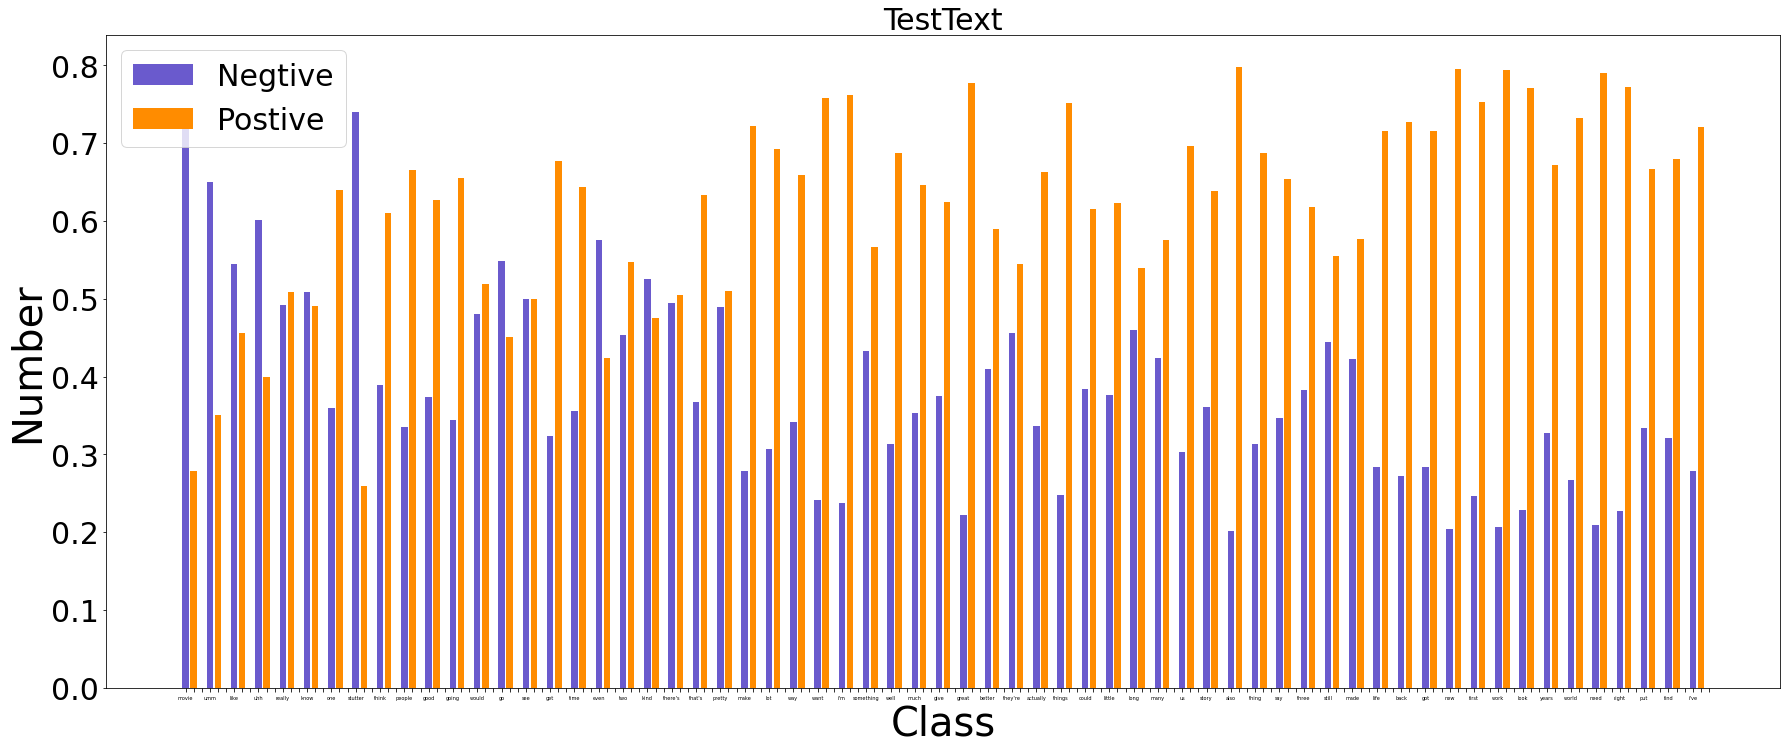

In [94]:
# non-negtive
for i in range(len(all_word_dict_1)):
    word = all_word_dict_1[i][0]
    for j in range(len(all_word_dict_0)):
        if all_word_dict_0[j][0] == word:
            lst = list(all_word_dict_1[i])
            sum = all_word_dict_1[i][1] + all_word_dict_0[j][1]
            all_word_dict_0[j] = tuple((word, all_word_dict_0[j][1]/sum))
            all_word_dict_1[i] = tuple((word, all_word_dict_1[i][1]/sum))
Mybar(all_word_dict_0, all_word_dict_1, "TestText")

['umm', 'like', 'really', 'uhh', 'one', 'movie', 'know', 'people', 'good', 'think', 'going', 'would', 'see', 'time', 'get', "i'm", 'make', 'lot', "that's", 'want', 'go', 'well', 'great', 'way', 'stutter', 'even', 'two', "there's", 'also', 'pretty', 'actually', 'much', 'things', 'little', 'could', 'kind', 'something', 'us', 'help', 'customer', 'better', 'give', 'money', 'new', 'many', 'work', 'three', 'five', 'right', 'story', "they're", 'long', 'love', 'back', 'say', 'thing', 'easy', 'use', 'look', 'made', 'world', 'got', 'service', 'maybe', 'life', 'film', 'still', 'watch', 'bit', 'check', 'around', 'mean', 'need', 'students', 'first', 'probably', 'movies', 'fact', 'real', 'audience', 'special', 'definitely', "i've", 'place', 'years', 'online', 'program', 'okay', 'find', 'said', 'best', 'united', 'big', 'bad', 'family', 'show', 'whole', 'book', 'gonna', 'team']


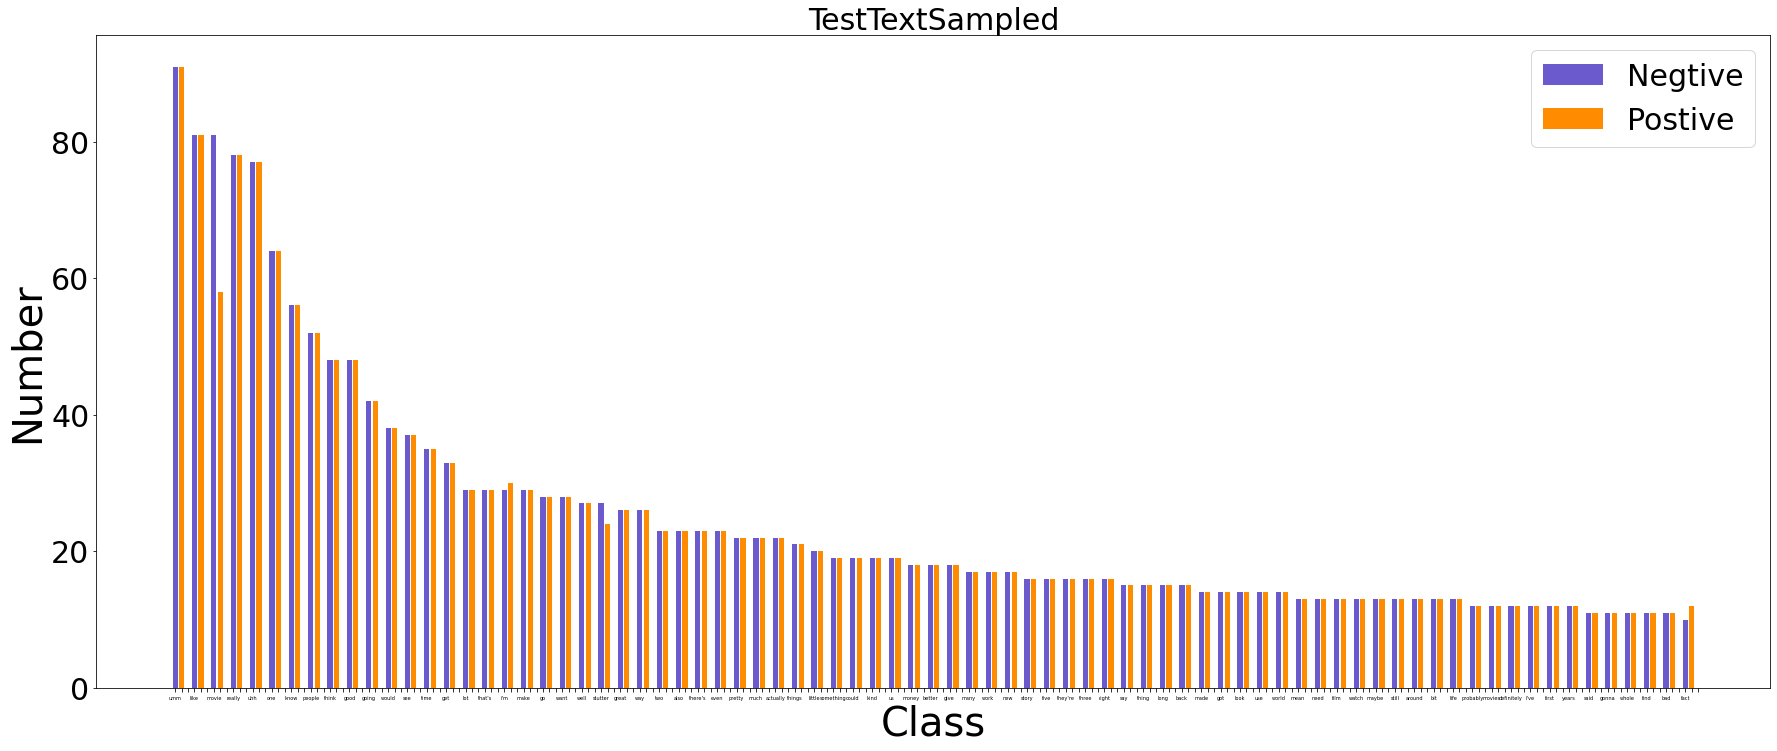

In [95]:
Mybar(test_word_dict_0, test_word_dict_1, "TestTextSampled")

In [ ]:
featurePath = "/home/st/disk0/ni/MMSA/MOSEI/unaligned_50.pkl"
with open(featurePath, 'rb') as f:
    data_ood_text = pickle.load(f)

keep_index = test_sample_list

for key, value in data_ood_text['test'].items():
    data_ood_text['test'][key] = [data_ood_text['test'][key][i] for i in keep_index] 

filename = f'/home/st/disk0/ni/MMSA/MOSEI/{data_type}/data_ood_text.pkl'
with open(filename, 'wb') as f:
    pickle.dump(data_ood_text, f, protocol=4)